In [3]:
# snmf_env

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from matplotlib import cm
import os
import pickle as pkl
import umap

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

from SigProfilerAssignment import Analyzer as Analyze

%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize':(10.0,8.27)})


from SigProfilerMatrixGenerator import install as genInstall
genInstall.install('GRCh37')


# LOAD Bootstrapped functions
import sys
import os
# append project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import importlib
from src.processing import bootstrapping as boot
# Reload the module to ensure we have the latest version
importlib.reload(boot)




/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tool       | Installed 
-----------------------
curl       | True      
wget       | False     
rsync      | True      


INFO - GRCh37 is already installed.


All reference files have been created.
To proceed with matrix_generation, please provide the path to your vcf files and an appropriate output path.
Installation complete.


<module 'src.processing.bootstrapping' from '/Users/sande/Projects/SNMF/src/processing/bootstrapping.py'>

# Load Gene KO cell lines Zou

In [11]:
import os
import pandas as pd

# --- Setup ---
project_root = "/Users/sande/Documents/GitHub/SNMF"
real_data_path = os.path.join(project_root, "data", "processed", "real", "zou_all.pkl")
output_dir = os.path.join(project_root, "data", "processed", "real")
N_train, N_test = 100, 1000
fixed_class_order = ["Control", "MMR", "HR", "BER"]

# --- Load consolidated real dataset ---
df_real = pd.read_pickle(real_data_path)

# Add label_name column to df_real by mapping numeric label to pathway name
df_real["label_name"] = df_real["label"].map(lambda x: fixed_class_order[x] if 0 <= x < len(fixed_class_order) else "Unknown")

# --- Split into folds by original source ---
folds = {
    "train1": df_real[df_real["source"] == "train1"].copy(),
    "train2": df_real[df_real["source"] == "train2"].copy(),
    "train3": df_real[df_real["source"] == "train3"].copy(),
    "test":   df_real[df_real["source"] == "test"].copy(),
}

# --- Make real indices consistent with bootstrap indices: GENE_idx_real_trainX ---
for fold_name, df in folds.items():
    # per-gene running index (0,1,2,...) — stable within each fold
    real_idx = df.groupby("Gene_KO").cumcount().astype(str)
    # build new index: e.g., ATP2B4_5_real_train3
    new_index = df["Gene_KO"].astype(str) + "_" + real_idx + "_real_" + fold_name
    # keep old index if you want to debug later
    df["old_index"] = df.index.astype(str)
    df.index = new_index
    folds[fold_name] = df

# (optional) quick sanity check
# print({k: folds[k].index[:3].tolist() for k in folds})


In [12]:

# --- Extract mutation features ---
features = df_real.columns[:96]

fixed_class_order = ["Control", "MMR", "HR", "BER"]
# --- Save per-fold real X and Y files ---
for fold_name, df in folds.items():
    X = df.loc[:, features]
    y = df["label_name"]

    X_path = os.path.join(output_dir, f"Xreal_{fold_name}.text")
    y_path = os.path.join(output_dir, f"Yreal_{fold_name}.text")
    os.makedirs(os.path.dirname(X_path), exist_ok=True)

    X.T.to_csv(X_path, sep="\t")
    
    y_onehot = pd.get_dummies(y).astype(float).T
    y_onehot = y_onehot.reindex(fixed_class_order, fill_value=0)
    y_onehot.to_csv(y_path, sep="\t")


# --- Build combined train/test sets ---
Xreal_train = pd.concat([folds["train1"][features], folds["train2"][features], folds["train3"][features]])
Yreal_train = pd.concat([folds["train1"]["label_name"], folds["train2"]["label_name"], folds["train3"]["label_name"]])

Xreal_test = folds["test"][features]
Yreal_test = folds["test"]["label_name"]

# --- Save combined real train/test sets ---
combined_train_path_X = os.path.join(output_dir, "Xreal_train.text")
combined_train_path_Y = os.path.join(output_dir, "Yreal_train.text")
combined_test_path_X = os.path.join(output_dir, "Xreal_test.text")
combined_test_path_Y = os.path.join(output_dir, "Yreal_test.text")

# Xreal_train.T.to_csv(combined_train_path_X, sep="\t")
# pd.get_dummies(Yreal_train).astype(float).T.to_csv(combined_train_path_Y, sep="\t")

# Xreal_test.T.to_csv(combined_test_path_X, sep="\t")
# pd.get_dummies(Yreal_test).astype(float).T.to_csv(combined_test_path_Y, sep="\t")


y_onehot_train = pd.get_dummies(Yreal_train).astype(float).T
y_onehot_train.index = fixed_class_order  # rename rows directly
y_onehot_train = y_onehot_train.reindex(fixed_class_order, fill_value=0)
y_onehot_train.index.name = None  # remove index name header
y_onehot_train.to_csv(combined_train_path_Y, sep="\t", index=True, header=True)  # keep index as row names (class labels)
y_onehot_train.to_csv(combined_train_path_Y, sep="\t")

y_onehot_test = pd.get_dummies(Yreal_test).astype(float).T
y_onehot_test.index = fixed_class_order  # rename rows directly
y_onehot_test = y_onehot_test.reindex(fixed_class_order, fill_value=0)
y_onehot_test.index.name = None  # remove index name header
y_onehot_test.to_csv(combined_test_path_Y, sep="\t", index=True, header=True)  # keep index as row names (class labels)



# Bootstrap

In [14]:
import sys
import os
import importlib

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.processing import bootstrapping as boot
importlib.reload(boot)

# --- Setup ---
N_train = 100 
N_test = 1000
ds = 100  # Dirichlet strength (low is more noise)

XbootM_train_1, XbootD_train_1 = boot.bootstrap_dirichlet(folds["train1"], L=N_train, dirichlet_strength=ds, suffix="train1", class_col='label')
XbootM_train_2, XbootD_train_2 = boot.bootstrap_dirichlet(folds["train2"], L=N_train, dirichlet_strength=ds, suffix="train2", class_col='label')
XbootM_train_3, XbootD_train_3 = boot.bootstrap_dirichlet(folds["train3"], L=N_train, dirichlet_strength=ds, suffix="train3", class_col='label')
XbootM_test,    XbootD_test    = boot.bootstrap_dirichlet(folds["test"],   L=N_test, dirichlet_strength=ds, suffix="test", class_col='label')


In [20]:
### Store bootstrapped matrices

# --- Setup ---
# project_root = "/Users/sande/Documents/GitHub/SNMF"

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
print("📁 Project root:", project_root)

# --- Bootstrapped matrices assumed to exist ---
# XbootD_train_1, XbootD_train_2, XbootD_train_3, XbootD_test
# XbootM_train_1, XbootM_train_2, XbootM_train_3, XbootM_test

# --- Create output dirs ---
dirichlet_dir_train = os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_train}")
dirichlet_dir_test  = os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_test}")
multinom_dir_train  = os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_train}")
multinom_dir_test   = os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_test}")

for d in [dirichlet_dir_train, dirichlet_dir_test, multinom_dir_train, multinom_dir_test]:
    os.makedirs(d, exist_ok=True)

# # --- Save helper ---
# def save_bootstrapped_split(Xboot, suffix, outdir, prefix="D"):
#     path_X = os.path.join(outdir, f"Xboot{prefix}_{suffix}.text")
#     path_Y = os.path.join(outdir, f"Yboot{prefix}_{suffix}.text")

#     # --- Extract only the 96 mutation features ---
#     mut_cols = Xboot.columns[:96]
#     X_numeric = Xboot[mut_cols]

#     # Save features (transpose so samples are columns)
#     X_numeric.T.to_csv(path_X, sep="\t")

#     # Extract labels for each sample (column) from metadata
#     labels = Xboot["label"]

#     # Create one-hot encoded DataFrame (classes as rows, samples as columns)
#     y_onehot = pd.get_dummies(labels).T
#     y_onehot.columns = Xboot.index  # match sample names as columns

#     # Save labels
#     y_onehot.to_csv(path_Y, sep="\t")
fixed_class_order = ["Control", "MMR", "HR", "BER"]

def save_bootstrapped_split(Xboot, suffix, outdir, prefix="D"):
    os.makedirs(outdir, exist_ok=True)
    path_X = os.path.join(outdir, f"Xboot{prefix}_{suffix}.text")
    path_Y = os.path.join(outdir, f"Yboot{prefix}_{suffix}.text")

    # --- Extract only the 96 mutation features ---
    mut_cols = Xboot.columns[:96]
    X_numeric = Xboot[mut_cols]
    X_numeric.T.to_csv(path_X, sep="\t")

    # --- Get labels safely ---
    labels = Xboot["label_name"] if "label_name" in Xboot.columns else Xboot["label"]

    # --- One-hot encode ---
    y_onehot = pd.get_dummies(labels).T
    y_onehot = y_onehot.reindex(fixed_class_order, fill_value=0)
    y_onehot.columns = Xboot.index


    # --- Save ---
    y_onehot.to_csv(path_Y, sep="\t")

    print(f"Saved: {path_X} and {path_Y}")



# --- Save Dirichlet ---
save_bootstrapped_split(XbootD_train_1, "train1", dirichlet_dir_train, "D")
save_bootstrapped_split(XbootD_train_2, "train2", dirichlet_dir_train, "D")
save_bootstrapped_split(XbootD_train_3, "train3", dirichlet_dir_train, "D")
save_bootstrapped_split(XbootD_test,    "test",   dirichlet_dir_test,  "D")

# Combine all train folds
XbootD_train_all = pd.concat([XbootD_train_1, XbootD_train_2, XbootD_train_3], axis=0)
save_bootstrapped_split(XbootD_train_all, "train_all", dirichlet_dir_train, "D")

# --- Save Multinomial ---
save_bootstrapped_split(XbootM_train_1, "train1", multinom_dir_train, "M")
save_bootstrapped_split(XbootM_train_2, "train2", multinom_dir_train, "M")
save_bootstrapped_split(XbootM_train_3, "train3", multinom_dir_train, "M")
save_bootstrapped_split(XbootM_test,    "test",   multinom_dir_test,  "M")

XbootM_train_all = pd.concat([XbootM_train_1, XbootM_train_2, XbootM_train_3], axis=0)
save_bootstrapped_split(XbootM_train_all, "train_all", multinom_dir_train, "M")


📁 Project root: /Users/sande/Projects/SNMF
Saved: /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/XbootD_train1.text and /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/YbootD_train1.text
Saved: /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/XbootD_train2.text and /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/YbootD_train2.text
Saved: /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/XbootD_train3.text and /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/YbootD_train3.text
Saved: /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_1000/XbootD_test.text and /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_1000/YbootD_test.text
Saved: /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/XbootD_train_all.text and /Users/sande/Projects/SNMF/data/processed/bootstrapped_dirichlet/N_100/YbootD_train_all.tex

In [15]:
XbootM_test

,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T,A[C>T]A,A[C>T]C,...,Subpathway_KO,label,boot,Gene_KO_paired,Subpathway_KO_paired,source,split,label_name,old_index,boot_method
EXO1_2_real_test,0.028554,0.013366,0.006683,0.013973,0.009721,0.008505,0.009113,0.006075,0.012151,0.011543,...,HR and HR regulation,2,False,EXO1_2,HR and HR regulation_real,test,test,HR,test_EXO1_2_real,real
OGG1_3_real_test,0.136490,0.006964,0.001393,0.018106,0.001393,0.000000,0.000000,0.000000,0.009749,0.001393,...,BER,3,False,OGG1_3,BER_real,test,test,BER,test_OGG1_3_real,real
RNF168_3_real_test,0.035183,0.018945,0.006766,0.013532,0.013532,0.006766,0.012179,0.009472,0.024357,0.005413,...,Checkpoint/DSB repair,2,False,RNF168_3,Checkpoint/DSB repair_real,test,test,HR,test_RNF168_3_real,real
UNG_3_real_test,0.026201,0.004367,0.000000,0.004367,0.000000,0.000000,0.004367,0.000000,0.078603,0.021834,...,BER,3,False,UNG_3,BER_real,test,test,BER,test_UNG_3_real,real
ATP2B4_6_real_test,0.051793,0.003984,0.003984,0.019920,0.000000,0.003984,0.003984,0.007968,0.023904,0.011952,...,Control,0,False,ATP2B4_6,Control_real,test,test,Control,test_ATP2B4_6_real,real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSH2_2_multinomial_test,0.006050,0.002161,0.000864,0.009939,0.004322,0.000432,0.000000,0.005618,0.056180,0.014693,...,MMR,1,True,MSH2_2,MMR_real,test,test,MMR,test_MSH2_2_real,multinomial
MLH1_3_multinomial_test,0.012183,0.001949,0.000975,0.007797,0.005361,0.000000,0.000487,0.001949,0.057992,0.014620,...,MMR,1,True,MLH1_3,MMR_real,test,test,MMR,test_MLH1_3_real,multinomial
MSH2_2_multinomial_test,0.006482,0.002593,0.000432,0.006482,0.001729,0.000432,0.000000,0.002593,0.050130,0.020311,...,MMR,1,True,MSH2_2,MMR_real,test,test,MMR,test_MSH2_2_real,multinomial
MSH2_2_multinomial_test,0.004322,0.000432,0.001729,0.005618,0.003889,0.000000,0.000000,0.003889,0.057476,0.019879,...,MMR,1,True,MSH2_2,MMR_real,test,test,MMR,test_MSH2_2_real,multinomial


## UMAP: Train/Test split distribution

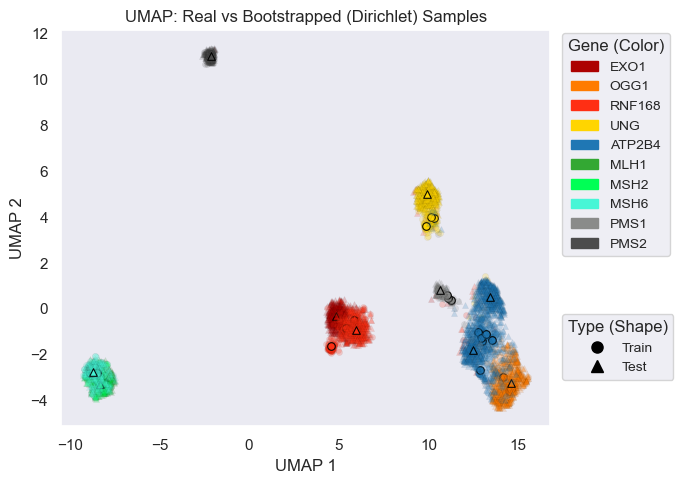

Saved supplementary figure to /Users/sande/Documents/GitHub/SNMF/results/figures/sup/bootstrapping/umap_bootstrap_dirichlet_Ntrain100_Ntest1000.pdf


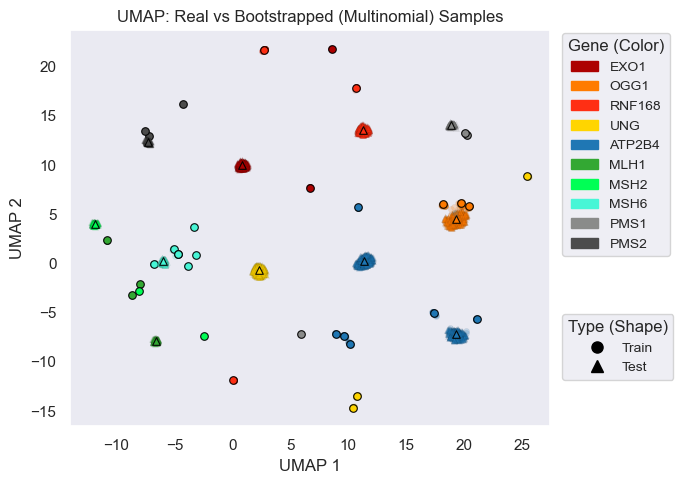

Saved supplementary figure to /Users/sande/Documents/GitHub/SNMF/results/figures/sup/bootstrapping/umap_bootstrap_multinomial_Ntrain100_Ntest1000.pdf


In [12]:
import os
import re
import pandas as pd
import importlib
import matplotlib.pyplot as plt
from src.processing import bootstrapping as boot
importlib.reload(boot)

project_root = "/Users/sande/Documents/GitHub/SNMF"
N_train, N_test = 100, 1000

# where to save (supplementary bootstrapping)
fig_dir = os.path.join(project_root, "results", "figures", "sup", "bootstrapping")
os.makedirs(fig_dir, exist_ok=True)

dirs = {
    "D": {
        "train1": os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_train}", "XbootD_train1.text"),
        "train2": os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_train}", "XbootD_train2.text"),
        "train3": os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_train}", "XbootD_train3.text"),
        "test":   os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet", f"N_{N_test}",  "XbootD_test.text"),
    },
    "M": {
        "train1": os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_train}", "XbootM_train1.text"),
        "train2": os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_train}", "XbootM_train2.text"),
        "train3": os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_train}", "XbootM_train3.text"),
        "test":   os.path.join(project_root, "data", "processed", "bootstrapped_multinomial", f"N_{N_test}",  "XbootM_test.text"),
    }
}

def load_X(path):
    # stored as contexts x samples; transpose so rows=samples, cols=features
    return pd.read_csv(path, sep="\t", index_col=0).T

def parse_metadata_from_index(idx):
    genes, boots, splits = [], [], []
    for s in idx:
        gene = s.split("_")[0]
        name_l = s.lower()
        is_real = "_real" in name_l
        is_boot = ("multinomial" in name_l) or ("dirichlet" in name_l) or ("boot" in name_l and not is_real)
        m = re.search(r"(train1|train2|train3|test)$", s)
        split = m.group(1) if m else ("test" if "test" in name_l else "train")
        genes.append(gene); boots.append(False if is_real else bool(is_boot)); splits.append(split)
    return (pd.Series(genes,  index=idx, name="Gene_KO"),
            pd.Series(boots,  index=idx, name="boot"),
            pd.Series(splits, index=idx, name="split"))

def prep_for_umap(paths_dict, title_prefix, save_basename):
    # concat all splits
    X = pd.concat([load_X(p) for p in paths_dict.values()], axis=0)
    gene, bootflag, split = parse_metadata_from_index(X.index)

    # attach required metadata columns
    X = X.copy()
    X["Gene_KO"] = gene
    X["boot"]    = bootflag
    X["split"]   = split

    # split into real vs boot using the parsed flag
    X_real = X[X["boot"] == False].copy()
    X_boot = X[X["boot"] == True].copy()

    # save path
    fig_path = os.path.join(fig_dir, f"{save_basename}.pdf")

    # make + save (boot.make_umap_plot should support save_path & show)
    fig, ax = boot.make_umap_plot(
        X_real=X_real,
        X_boot=X_boot,
        title=title_prefix,
        save_path=fig_path,
        show=True
    )
    plt.close(fig)
    print(f"Saved supplementary figure to {fig_path}")

# --- Make & save UMAPs ---
prep_for_umap(dirs["D"], "UMAP: Real vs Bootstrapped (Dirichlet) Samples",
              save_basename=f"umap_bootstrap_dirichlet_Ntrain{N_train}_Ntest{N_test}")

prep_for_umap(dirs["M"], "UMAP: Real vs Bootstrapped (Multinomial) Samples",
              save_basename=f"umap_bootstrap_multinomial_Ntrain{N_train}_Ntest{N_test}")


# Classifier: Train/Test split distribution

In [13]:
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# ---------- Index parsing + metadata ----------

# def add_metadata_from_index(df: pd.DataFrame) -> pd.DataFrame:
#     """Parse index into Gene_KO, real_idx, fold, split, and boot flag."""
#     out = df.copy()
#     idx = out.index.astype(str)

#     # Gene_KO and real index
#     token0 = idx.str.split("_").str[0]
#     token1 = idx.str.split("_").str[1].fillna("")
#     out["Gene_KO"] = token0
#     out["real_idx"] = token1
#     out["Gene_KO_paired"] = token0 + "_" + token1

#     # Split: train vs test (from suffix if present, else infer)
#     tail = pd.Series(idx.str.extract(r'(train[123]|test)$', expand=False), index=out.index)
#     base = np.where(idx.str.contains(r'test', case=False), "test", "train")
#     out["split"] = np.where(tail.notna(), tail, base)

#     # Boot flag
#     low = idx.str.lower()
#     out["boot"] = (~low.str.contains(r'_real')) & (
#         low.str.contains('multinomial') | low.str.contains('dirichlet') | low.str.contains('boot')
#     )
#     return out

# def ensure_metadata(df: pd.DataFrame) -> pd.DataFrame:
#     """Ensure metadata columns are present."""
#     needed = {"Gene_KO", "real_idx", "Gene_KO_paired", "split", "boot"}
#     if not needed.issubset(df.columns):
#         return add_metadata_from_index(df)
#     return df
import numpy as np
import pandas as pd
import re

_fold_tail_re = re.compile(r'(train[123]|test)$', re.IGNORECASE)

def add_metadata_from_index(df: pd.DataFrame) -> pd.DataFrame:
    """Parse index into Gene_KO, real_idx, Gene_KO_paired, fold (train1/2/3/test), split (train/test), and boot flag."""
    out = df.copy()

    # work with a Series version of the index (keeps alignment)
    sidx = pd.Series(out.index.astype(str), index=out.index)

    # tokens
    toks = sidx.str.split("_")
    gene   = toks.str[0]
    real_i = toks.str[1].fillna("")
    out["Gene_KO"]        = gene
    out["real_idx"]       = real_i
    out["Gene_KO_paired"] = gene + "_" + real_i

    # fold: explicit tail if present, else fallback by substring search (test/train3/train2/train1)
    tail = sidx.str.extract(_fold_tail_re, expand=False)  # Series aligned to index
    fallback_fold = np.where(
        sidx.str.contains(r'test', case=False),  "test",
        np.where(sidx.str.contains(r'train3', case=False), "train3",
        np.where(sidx.str.contains(r'train2', case=False), "train2",
        np.where(sidx.str.contains(r'train1', case=False), "train1", "train1")))
    )
    # combine tail and fallback safely
    fold_series = tail.astype(object).combine_first(pd.Series(fallback_fold, index=out.index))
    out["fold"] = fold_series.str.lower()

    # split: binary from fold
    out["split"] = np.where(out["fold"] == "test", "test", "train")

    # boot flag
    low = sidx.str.lower()
    out["boot"] = (~low.str.contains(r'_real')) & (
        low.str.contains('multinomial') | low.str.contains('dirichlet') | low.str.contains('boot')
    )
    return out


def ensure_metadata(df: pd.DataFrame) -> pd.DataFrame:
    needed = {"Gene_KO", "real_idx", "Gene_KO_paired", "fold", "split", "boot"}
    return df if needed.issubset(df.columns) else add_metadata_from_index(df)




# ---------- Matching stratified folds ----------

def match_bootstrap_by_paired_key(real_subset: pd.DataFrame,
                                  bootstrap_df: pd.DataFrame) -> pd.DataFrame:
    """Return bootstrap rows whose Gene_KO_paired appears in the real subset."""
    # R = ensure_metadata(real_subset)
    # B = ensure_metadata(bootstrap_df)
    R = real_subset.copy()
    B = bootstrap_df.copy()

    keys = set(R["Gene_KO_paired"].astype(str))
    mask = B["Gene_KO_paired"].astype(str).isin(keys)
    return B.loc[mask].copy()

def stratified_fold_from_real(X_boot_all: pd.DataFrame,
                              real_train: pd.DataFrame,
                              real_test: pd.DataFrame):
    """Split bootstraps using Gene_KO_paired keys derived from index."""
    boot_train = match_bootstrap_by_paired_key(real_train, X_boot_all)
    boot_test  = match_bootstrap_by_paired_key(real_test,  X_boot_all)
    return boot_train, boot_test


# ---------- Random fold (general) ----------

def random_fold(X_train: pd.DataFrame, X_test: pd.DataFrame, test_size=0.3, random_state=42):
    """Random split keeping 'split' = target variable (train vs test)."""
    X_all = pd.concat([X_train, X_test], axis=0).copy()
    # X_all = ensure_metadata(X_all)
    y_all = (X_all["split"].values == "test").astype(int)
    tr, te, _, _ = train_test_split(X_all, y_all, test_size=test_size,
                                    random_state=random_state, stratify=y_all)
    return tr, te


# ---------- Balanced random fold for REAL samples ----------

def balanced_random_fold_real(X_train_real: pd.DataFrame, X_test_real: pd.DataFrame,
                              test_size=0.3, random_state=42):
    """Random split of real samples ensuring each Gene_KO has ≥1 in train and test."""
    rng = np.random.RandomState(random_state)
    X_all = pd.concat([X_train_real, X_test_real], axis=0).copy()
    # X_all = ensure_metadata(X_all)

    train_idx, test_idx = [], []
    for gene, grp in X_all.groupby("Gene_KO"):
        idxs = grp.index.tolist()
        rng.shuffle(idxs)
        n = len(idxs)

        if n == 1:
            train_idx.append(idxs[0])
            continue

        # Guarantee at least one in each split
        train_idx.append(idxs[0])
        test_idx.append(idxs[1])

        remaining = idxs[2:]
        target_test = max(1, int(round(test_size * n)))
        need_more_test = max(0, target_test - 1)
        test_idx.extend(remaining[:need_more_test])
        train_idx.extend(remaining[need_more_test:])

    train_df = X_all.loc[sorted(set(train_idx))].copy()
    test_df  = X_all.loc[sorted(set(test_idx))].copy()
    train_df["split"] = "train"
    test_df["split"]  = "test"
    return train_df, test_df


# ---------- Classifier ----------

def classifier_train_vs_test(X_train_all: pd.DataFrame, X_test_all: pd.DataFrame, description: str = ""):
    """Train classifier to distinguish train vs test samples."""
    # X_train_all = ensure_metadata(X_train_all)
    # X_test_all  = ensure_metadata(X_test_all)

    Xtr = X_train_all.iloc[:, :96].values
    Xte = X_test_all.iloc[:, :96].values
    ytr = (X_train_all["split"] == "test").astype(int).values
    yte = (X_test_all["split"] == "test").astype(int).values

    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    clf = LogisticRegression(max_iter=1000, random_state=42, solver='saga', penalty='l2', class_weight='balanced')
    clf.fit(Xtr_s, ytr)
    yhat = clf.predict(Xte_s)

    acc = accuracy_score(yte, yhat)
    f1  = f1_score(yte, yhat)
    print(f"{description} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

    X_train_all = X_train_all.copy(); X_test_all = X_test_all.copy()
    X_train_all["pred"] = clf.predict(Xtr_s)
    X_test_all["pred"]  = yhat
    return X_train_all, X_test_all


In [14]:
# --- Load back bootstrapped splits ---
XbootM_train_1 = load_X(dirs["M"]["train1"])
XbootM_train_2 = load_X(dirs["M"]["train2"])
XbootM_train_3 = load_X(dirs["M"]["train3"])
XbootM_test    = load_X(dirs["M"]["test"])

XbootD_train_1 = load_X(dirs["D"]["train1"])
XbootD_train_2 = load_X(dirs["D"]["train2"])
XbootD_train_3 = load_X(dirs["D"]["train3"])
XbootD_test    = load_X(dirs["D"]["test"])

# After loading:
XbootM_train_1 = ensure_metadata(XbootM_train_1)
XbootM_train_2 = ensure_metadata(XbootM_train_2)
XbootM_train_3 = ensure_metadata(XbootM_train_3)
XbootM_test    = ensure_metadata(XbootM_test)
XbootD_train_1 = ensure_metadata(XbootD_train_1)
XbootD_train_2 = ensure_metadata(XbootD_train_2)
XbootD_train_3 = ensure_metadata(XbootD_train_3)
XbootD_test    = ensure_metadata(XbootD_test)

# Build train_all and ensure metadata there too
XbootM_train_all = ensure_metadata(pd.concat([XbootM_train_1, XbootM_train_2, XbootM_train_3], axis=0))
XbootD_train_all = ensure_metadata(pd.concat([XbootD_train_1, XbootD_train_2, XbootD_train_3], axis=0))

# Random folds
M_train_random, M_test_random = random_fold(XbootM_train_all, XbootM_test)
M_train_random, M_test_random = classifier_train_vs_test(M_train_random, M_test_random, "Multinomial Bootstrap - Random")

D_train_random, D_test_random = random_fold(XbootD_train_all, XbootD_test)
D_train_random, D_test_random = classifier_train_vs_test(D_train_random, D_test_random, "Dirichlet Bootstrap - Random")

# Real random fold
df_real_train = pd.concat([folds["train1"], folds["train2"], folds["train3"]])
df_real_test = folds["test"]

# Real_train_random, Real_test_random = balanced_random_fold_real(df_real_train, df_real_test)
Real_train_random, Real_test_random = random_fold(df_real_train, df_real_test)
Real_train_random, Real_test_random = classifier_train_vs_test(Real_train_random, Real_test_random, "Real Samples - Balanced Random")

# Stratified folds
XbootM_all = pd.concat([XbootM_train_all, XbootM_test], axis=0)
M_train_strat, M_test_strat = stratified_fold_from_real(XbootM_all, Real_train_random, Real_test_random)
M_train_strat, M_test_strat = classifier_train_vs_test(M_train_strat, M_test_strat, "Multinomial Bootstrap - Stratified")

XbootD_all = pd.concat([XbootD_train_all, XbootD_test], axis=0)
D_train_strat, D_test_strat = stratified_fold_from_real(XbootD_all, Real_train_random, Real_test_random)
D_train_strat, D_test_strat = classifier_train_vs_test(D_train_strat, D_test_strat, "Dirichlet Bootstrap - Stratified")



Multinomial Bootstrap - Random → Accuracy: 0.9314 | F1: 0.9544
Dirichlet Bootstrap - Random → Accuracy: 0.7314 | F1: 0.8082
Real Samples - Balanced Random → Accuracy: 0.5000 | F1: 0.2222
Multinomial Bootstrap - Stratified → Accuracy: 0.2564 | F1: 0.2686
Dirichlet Bootstrap - Stratified → Accuracy: 0.3869 | F1: 0.4995


In [19]:
from sklearn.metrics import accuracy_score

# --- Helper to print and compute mean ---
def report_grouped_accuracy(df, label):
    print(f"\nCounts and accuracy in {label} (by Gene_KO_paired and split):")
    test_grouped = df.groupby(['Gene_KO_paired', 'split'])
    accs = []  # store per-group accuracies (equal weight)
    for (gene_ko, split), group in test_grouped:
        count = len(group)
        true_vals = (group['split'] == "test").astype(int)
        if 'pred' in group.columns:
            acc = accuracy_score(true_vals, group['pred'])
            accs.append(acc)
            print(f"{gene_ko:20} | {split} | Count: {count:3d} | Accuracy: {acc:.3f}")
        else:
            print(f"{gene_ko:20} | {split} | Count: {count:3d} | Accuracy: N/A")

    if accs:
        mean_acc = np.mean(accs)
        print(f"\nMean accuracy across Gene_KO_paired groups (unweighted): {mean_acc:.3f}")

# --- Dirichlet stratified ---
report_grouped_accuracy(D_test_strat, "D_test_strat (Dirichlet stratified)")

# --- Multinomial stratified ---
report_grouped_accuracy(M_test_strat, "M_test_strat (Multinomial stratified)")




Counts and accuracy in D_test_strat (Dirichlet stratified) (by Gene_KO_paired and split):
EXO1_1               | train | Count:  44 | Accuracy: 0.455
MLH1_0               | train | Count:  20 | Accuracy: 0.400
MLH1_2               | train | Count:  13 | Accuracy: 0.385
MLH1_3               | test | Count: 196 | Accuracy: 0.740
MSH2_0               | train | Count:  15 | Accuracy: 0.400
MSH6_2               | train | Count:  23 | Accuracy: 0.522
MSH6_5               | train | Count:  24 | Accuracy: 0.375
PMS1_0               | train | Count:  24 | Accuracy: 0.125
PMS1_1               | train | Count:  13 | Accuracy: 0.077
PMS2_2               | train | Count:  11 | Accuracy: 0.364
RNF168_3             | test | Count: 504 | Accuracy: 0.349
UNG_1                | train | Count:  56 | Accuracy: 0.411
UNG_2                | train | Count:  53 | Accuracy: 0.566
UNG_3                | test | Count: 498 | Accuracy: 0.273

Mean accuracy across Gene_KO_paired groups (unweighted): 0.389

Counts 

Saved supplementary figure to /Users/sande/Documents/GitHub/SNMF/SNMF/results/figures/sup/bootstrapping/grouped_accuracy_per_geneKO.pdf


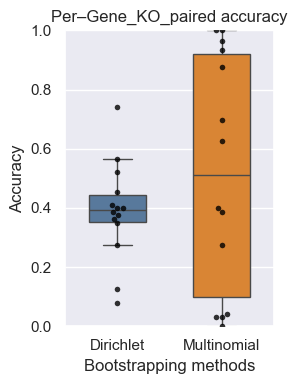

In [21]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
import seaborn as sns

# Define figure directory (supplementary bootstrapping)
fig_dir = os.path.join(project_root, "SNMF", "results", "figures", "sup", "bootstrapping")
os.makedirs(fig_dir, exist_ok=True)

def plot_grouped_accuracy(D_test_strat, M_test_strat, save_name="grouped_accuracy.pdf"):
    def collect_grouped_accuracy(df):
        accs = []
        for (gko, split), group in df.groupby(['Gene_KO_paired', 'split']):
            if 'pred' in group.columns:
                y_true = (group['split'] == "test").astype(int)
                accs.append({"Gene_KO_paired": gko, "split": split,
                             "accuracy": accuracy_score(y_true, group['pred'])})
        return pd.DataFrame(accs)

    acc_dir = collect_grouped_accuracy(D_test_strat); acc_dir["boot_type"] = "Dirichlet"
    acc_mul = collect_grouped_accuracy(M_test_strat); acc_mul["boot_type"] = "Multinomial"
    acc_all = pd.concat([acc_dir, acc_mul], ignore_index=True)

    plt.figure(figsize=(3, 4))
    palette = {"Dirichlet": "#4C78A8", "Multinomial": "#F58518"}

    sns.boxplot(data=acc_all, x="boot_type", y="accuracy", palette=palette,
                width=0.55, fliersize=0, linewidth=1)
    sns.swarmplot(data=acc_all, x="boot_type", y="accuracy",
                  color="black", size=4, alpha=0.8)

    plt.ylim(0, 1)
    plt.xlabel("Bootstrapping methods")
    plt.ylabel("Accuracy")
    plt.title("Per–Gene_KO_paired accuracy")
    plt.tight_layout()

    # --- Save figure ---
    save_path = os.path.join(fig_dir, save_name)
    plt.savefig(save_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"Saved supplementary figure to {save_path}")

    plt.show()
    plt.close()

# Example call:
plot_grouped_accuracy(D_test_strat, M_test_strat, save_name="grouped_accuracy_per_geneKO.pdf")


# Performance Comparison

## SNMF run [B/M]

In [99]:
import os
import pandas as pd
import numpy as np
import importlib
import SNMF.sigpro as sig

importlib.reload(sig)

# --- Settings ---
min_k = max_k = 5
reps = 10
lr = 5e-3
l_p = 0.0001
fold = '_all'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
# seed_path = os.path.join(project_root, "SNMF", "src", "CV", "Seeds_3.txt")

bootstrap_types = ["multinomial", "dirichlet"]
lc_values = [0.0, 0.1]
N_train, N_test = 100, 1000

# --- Master results container ---
results_df = pd.DataFrame()

for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"
    data_path = os.path.join(project_root, "data", "processed", f"bootstrapped_{bootstrap}")

    for l_c in lc_values:
        path_X_train = os.path.join(data_path, f"N_{N_train}", f"Xboot{prefix}_train{fold}.text")
        path_Y_train = os.path.join(data_path, f"N_{N_train}", f"Yboot{prefix}_train{fold}.text")
        path_X_test = os.path.join(data_path, f"N_{N_test}", f"Xboot{prefix}_test.text")
        path_Y_test = os.path.join(data_path, f"N_{N_test}", f"Yboot{prefix}_test.text")

        l_c_str = "0" if l_c == 0 else str(l_c).split('.')[-1]
        base_output_path = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"SNMF_results_{bootstrap}_lc{l_c_str}")

        for run in range(10):
            output_path = os.path.join(base_output_path, f"run_{run}")
            os.makedirs(output_path, exist_ok=True)
            print(f"Running {bootstrap} bootstrap, λ_c={l_c}, run {run+1}/10")
            
            # Train
            df_train = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                seeds='random',
                nmf_replicates=reps,
                lambda_c=l_c,
                lr=lr,
                lambda_p=l_p,
                make_decomposition_plots=False
            )


            # Test
            df_train[['acc_test', 'f1_test', 'rec_test']] = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # Add metadata on one line
            df_train = df_train.assign(k=min_k, lr=lr, lambda_c=l_c, lambda_p=l_p, fold=fold,
                                       bootstrap=bootstrap, run=run)

            results_df = pd.concat([results_df, df_train], ignore_index=True)

# --- Save all results ---
final_results_path = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", "SNMF_all_runs.csv")
results_df.to_csv(final_results_path, index=False)
print(f"Saved all SNMF results to: {final_results_path}")


Running multinomial bootstrap, λ_c=0.0, run 1/10

************** Reported Current Memory Use: 0.06 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.60 ; acc = 0.262
Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.48 ; acc = 0.252
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.45 ; acc = 0.273
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.47 ; acc = 0.278
Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.62 ; acc = 0.251Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.61 ; acc = 0.243

Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.43 ; acc = 0.284
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.48 ; acc = 0.285
Epoch: 100 ; Ltot = 2.21 ;  Lrec = 2.21 ; Lce = 273.62 ; acc = 0.927
Epoch: 100 ; Ltot = 2.22 ;  Lrec = 2.22 ; Lce = 316.95 ; acc = 0.913
Epoch: 100 ; Ltot = 2.31 ;  Lrec = 2.31 ; Lce = 437.14 ; acc = 0.872
Epoch: 100 ; Ltot = 2.20 ;  Lrec = 2.20 ; Lc

## Run Logistic Regression

In [97]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# --- Hyperparameter grid ---
param_grid = {'C': np.logspace(-2, 2, 11)}

# --- Run for both bootstraps ---
for bootstrap in ["multinomial", "dirichlet"]:
    prefix = "M" if bootstrap == "multinomial" else "D"
    project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
    data_dir = os.path.join(project_root, "data", "processed", f"bootstrapped_{bootstrap}")
    output_dir = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"LR_96sbs_{bootstrap}")
    os.makedirs(output_dir, exist_ok=True)

    # --- Load full train and test sets ---
    X_train_all = pd.read_csv(os.path.join(data_dir, "N_100", f"Xboot{prefix}_train_all.text"), sep="\t", index_col=0).T
    y_train_df = pd.read_csv(os.path.join(data_dir, "N_100", f"Yboot{prefix}_train_all.text"), sep="\t", index_col=0).T
    y_train_all = y_train_df.idxmax(axis=1)

    X_test = pd.read_csv(os.path.join(data_dir, "N_1000", f"Xboot{prefix}_test.text"), sep="\t", index_col=0).T
    y_test_df = pd.read_csv(os.path.join(data_dir, "N_1000", f"Yboot{prefix}_test.text"), sep="\t", index_col=0).T
    y_test = y_test_df.idxmax(axis=1)

    # --- Reconstruct folds from sample names ---
    folds = {f"train{i}": [] for i in range(1, 4)}
    for sample in X_train_all.index:
        for i in range(1, 4):
            if sample.endswith(f"_train{i}"):
                folds[f"train{i}"].append(sample)

    train_idx = [
        folds["train1"] + folds["train2"],
        folds["train1"] + folds["train3"],
        folds["train2"] + folds["train3"]
    ]
    val_idx = [
        folds["train3"],
        folds["train2"],
        folds["train1"]
    ]

    # --- Run 10x ---
    results = []
    seeds = []

    for run in range(10):
        seed = np.random.randint(1e6)
        seeds.append(seed)
        np.random.seed(seed)

        model = LogisticRegression(
            solver="saga", multi_class="multinomial", penalty="l2", max_iter=1000, random_state=seed
        )

        # Map sample names to integer indices
        name_to_idx = {name: i for i, name in enumerate(X_train_all.index)}
        train_idx_int = [[name_to_idx[s] for s in train_idx[i]] for i in range(3)]
        val_idx_int = [[name_to_idx[s] for s in val_idx[i]] for i in range(3)]
        custom_cv = [(train_idx_int[i], val_idx_int[i]) for i in range(3)]

        clf = GridSearchCV(model, param_grid, cv=custom_cv, scoring="f1_macro", refit=True)
        clf.fit(X_train_all.values, y_train_all.values)

        # Predict on test set
        y_pred = clf.predict(X_test.values)
        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        results.append({
            "run": run + 1,
            "seed": seed,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": clf.best_params_["C"]
        })

        print(f"[{bootstrap}] Run {run+1}: F1 = {f1:.4f}, Acc = {acc:.4f}, C = {clf.best_params_['C']}")

    # --- Save results ---
    df_results = pd.DataFrame(results)
    df_results_path = os.path.join(output_dir, f"lr_96sbs_runs.csv")
    df_results.to_csv(df_results_path, index=False)

    with open(os.path.join(output_dir, "seeds.txt"), "w") as f:
        f.writelines([f"{s}\n" for s in seeds])

    print(f"\nSaved results to: {df_results_path}")
    print(df_results.describe())


[multinomial] Run 1: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 2: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 3: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 4: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 5: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 6: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 7: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 8: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 9: F1 = 0.9645, Acc = 0.9645, C = 100.0
[multinomial] Run 10: F1 = 0.9645, Acc = 0.9645, C = 100.0

Saved results to: /Users/sande/Documents/GitHub/SNMF/results/analysis/bootstrap_comparison/LR_96sbs_multinomial/lr_96sbs_runs.csv
            run          seed      accuracy   f1_score        recall  best_C
count  10.00000      10.00000  1.000000e+01  10.000000  1.000000e+01    10.0
mean    5.50000  489494.60000  9.645000e-01   0.964507  9.645000e-01   100.0
std     3.02765  290286.32592  1.170278e-16   0.000000  1

### Run LR - Cosmic Exposures

In [100]:
# ===== LR - Ecosmic ======
# ! Get cosmic exposures
from SigProfilerAssignment import Analyzer as Analyze
import os
import pandas as pd


# --- Configuration ---
bootstrap_types = ["multinomial", "dirichlet"]
prefix_map = {"multinomial": "M", "dirichlet": "D"}
contexts = ["train_all", "test"]
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    input_dir = os.path.join(project_root, "data", "processed", f"bootstrapped_{bootstrap}")
    base_output_dir = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"cosmic_fit_{bootstrap}")
    os.makedirs(base_output_dir, exist_ok=True)

    for context in contexts:
        print(f"\n--- [{bootstrap.upper()}] Running COSMIC fit for: {context} ---")

        path_raw = os.path.join(input_dir, f"N_1000" if context == "test" else f"N_100", f"Xboot{prefix}_{context}.text")
        df = pd.read_csv(path_raw, sep="\t", index_col=0)

        df_scaled = df * 1000
        scaled_path = path_raw.replace(".text", "_1000x.text")
        df_scaled.to_csv(scaled_path, sep="\t", index_label="MutationType")

        # Save context-specific output
        output_dir_context = os.path.join(base_output_dir, context)
        os.makedirs(output_dir_context, exist_ok=True)

        Analyze.cosmic_fit(
            samples=scaled_path,
            output=output_dir_context,
            input_type="matrix",
            context_type="96",
            verbose=False
        )



--- [MULTINOMIAL] Running COSMIC fit for: train_all ---
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 

--- [MULTINOMIAL] Running COSMIC fit for: test ---
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 

--- [DIRICHLET] Running COSMIC fit for: train_all ---
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 

--- [DIRICHLET] Running COSMIC fit for: test ---
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


In [101]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# --- Hyperparameter grid ---
param_grid = {'C': np.logspace(-2, 2, 11)}

# --- Run for both bootstraps ---
for bootstrap in ["multinomial", "dirichlet"]:
    prefix = "M" if bootstrap == "multinomial" else "D"
    project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
    data_dir = os.path.join(project_root, "data", "processed", f"bootstrapped_{bootstrap}")
    exposure_dir = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"cosmic_fit_{bootstrap}")
    output_dir = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"LR_cosmic_{bootstrap}")
    os.makedirs(output_dir, exist_ok=True)

    # --- Load COSMIC exposures for train_all and test ---
    def load_exposures(context):
        path = os.path.join(exposure_dir, context, "Assignment_Solution", "Activities", "Assignment_Solution_Activities.txt")
        return pd.read_csv(path, sep="\t", index_col=0)

    X_train_all = load_exposures("train_all")
    X_test = load_exposures("test")

    # --- Load matching Y labels ---
    y_train_df = pd.read_csv(os.path.join(data_dir, "N_100", f"Yboot{prefix}_train_all.text"), sep="\t", index_col=0).T
    y_train_all = y_train_df.idxmax(axis=1)

    y_test_df = pd.read_csv(os.path.join(data_dir, "N_1000", f"Yboot{prefix}_test.text"), sep="\t", index_col=0).T
    y_test = y_test_df.idxmax(axis=1)

    # --- Reconstruct folds from sample names ---
    folds = {f"train{i}": [] for i in range(1, 4)}
    for sample in X_train_all.index:
        for i in range(1, 4):
            if sample.endswith(f"_train{i}"):
                folds[f"train{i}"].append(sample)

    train_idx = [
        folds["train1"] + folds["train2"],
        folds["train1"] + folds["train3"],
        folds["train2"] + folds["train3"]
    ]
    val_idx = [
        folds["train3"],
        folds["train2"],
        folds["train1"]
    ]

    # --- Run 10x ---
    results = []
    seeds = []

    for run in range(10):
        seed = np.random.randint(1e6)
        seeds.append(seed)
        np.random.seed(seed)

        model = LogisticRegression(
            solver="saga", multi_class="multinomial", penalty="l2", max_iter=1000, random_state=seed
        )

        # Map sample names to integer indices
        name_to_idx = {name: i for i, name in enumerate(X_train_all.index)}
        train_idx_int = [[name_to_idx[s] for s in train_idx[i]] for i in range(3)]
        val_idx_int = [[name_to_idx[s] for s in val_idx[i]] for i in range(3)]
        custom_cv = [(train_idx_int[i], val_idx_int[i]) for i in range(3)]

        clf = GridSearchCV(model, param_grid, cv=custom_cv, scoring="f1_macro", refit=True)
        clf.fit(X_train_all.values, y_train_all.loc[X_train_all.index].values)

        # Predict on test set
        y_pred = clf.predict(X_test.values)
        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        results.append({
            "run": run + 1,
            "seed": seed,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": clf.best_params_["C"]
        })

        print(f"[{bootstrap}] COSMIC Run {run+1}: F1 = {f1:.4f}, Acc = {acc:.4f}, C = {clf.best_params_['C']}")

    # --- Save results ---
    df_results = pd.DataFrame(results)
    results_path = os.path.join(output_dir, f"lr_cosmic_runs.csv")
    df_results.to_csv(results_path, index=False)

    with open(os.path.join(output_dir, "seeds.txt"), "w") as f:
        f.writelines([f"{s}\n" for s in seeds])

    print(f"\nSaved results to: {results_path}")
    print(df_results.describe())


[multinomial] COSMIC Run 1: F1 = 0.9685, Acc = 0.9685, C = 0.01
[multinomial] COSMIC Run 2: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 3: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 4: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 5: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 6: F1 = 0.9685, Acc = 0.9685, C = 0.01
[multinomial] COSMIC Run 7: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 8: F1 = 0.9685, Acc = 0.9685, C = 0.01
[multinomial] COSMIC Run 9: F1 = 0.9687, Acc = 0.9688, C = 0.01
[multinomial] COSMIC Run 10: F1 = 0.9687, Acc = 0.9688, C = 0.01

Saved results to: /Users/sande/Documents/GitHub/SNMF/results/analysis/bootstrap_comparison/LR_cosmic_multinomial/lr_cosmic_runs.csv
            run           seed   accuracy   f1_score     recall        best_C
count  10.00000      10.000000  10.000000  10.000000  10.000000  1.000000e+01
mean    5.50000  229371.200000   0.968675   0.968656   0.968675  1.000

In [ ]:
import SNMF.sigpro as sig
importlib.reload(sig)

# --- SNMF Settings ---
min_k = max_k = 5
reps = 10
lr = 5e-3
# l_c = 0.1
l_c = 0.1
l_p = 0.0001
fold = '_all'

# --- Initialize Results DataFrame ---
results_df = pd.DataFrame()

# --- Paths ---
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
seed_path = os.path.join(project_root, "SNMF", "src", "CV", "Seeds_3.txt")

# Path to save model (used in both training and testing)
l_c_str = "0" if l_c == 0 else str(l_c).split('.')[-1]
model_path = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"SNMF_results_multinomial_lc{l_c_str}")
output_path = model_path
os.makedirs(model_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

# Data paths
data_path = os.path.join(project_root, "data", "processed", "bootstrapped_multinomial")
N_train = 100
N_test = 1000

path_X_train = os.path.join(data_path, f"N_{N_train}", f"XbootM_train{fold}.text")
path_Y_train = os.path.join(data_path, f"N_{N_train}", f"YbootM_train{fold}.text")
path_X_test = os.path.join(data_path, f"N_{N_test}", "XbootM_test.text")
path_Y_test = os.path.join(data_path, f"N_{N_test}", "YbootM_test.text")

# --- Run SNMF Training ---
df_train = sig.sigProfilerExtractor(
    input_type="text",
    output=model_path,
    input_data=path_X_train,
    input_label=path_Y_train,
    minimum_signatures=min_k,
    maximum_signatures=max_k,
    seeds=seed_path,
    nmf_replicates=reps,
    lambda_c=l_c,
    lr=lr, 
    lambda_p=l_p,
    make_decomposition_plots=False
)

# --- Run SNMF Testing ---
df_train[['acc_test', 'f1_test', 'rec_test']] = sig.test_sigProfilerExtractor(
    input_type="text",
    model_path=model_path,
    output=output_path,
    test_data=path_X_test,
    test_label=path_Y_test,
    minimum_signatures=min_k,
    maximum_signatures=max_k,
    nmf_replicates=reps,
    lambda_c=l_c,
    lambda_p=l_p,
    lr=lr,
    filter=False,
    make_decomposition_plots=False
)

# --- Add Metadata ---
df_train = df_train.assign(
    k=min_k,
    lr=lr,
    lambda_c=l_c,
    lambda_p=l_p,
    fold=fold
)

# --- Store results ---
results_df = pd.concat([results_df, df_train], ignore_index=True)

# --- Save as CSV ---
results_csv_path = os.path.join(output_path, f"SNMF_k{min_k}_f{fold}.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved results to: {results_csv_path}")



************** Reported Current Memory Use: 0.73 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.62 ; acc = 0.248
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.61 ; acc = 0.241
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.31 ; acc = 0.310
Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.48 ; acc = 0.257
Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.55 ; acc = 0.231
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.59 ; acc = 0.257
Epoch: 0 ; Ltot = 8.18 ;  Lrec = 8.18 ; Lce = 1663.51 ; acc = 0.257
Epoch: 0 ; Ltot = 8.17 ;  Lrec = 8.17 ; Lce = 1663.66 ; acc = 0.230
Epoch: 100 ; Ltot = 2.29 ;  Lrec = 2.29 ; Lce = 534.31 ; acc = 0.877
Epoch: 100 ; Ltot = 2.24 ;  Lrec = 2.24 ; Lce = 348.73 ; acc = 0.911
Epoch: 100 ; Ltot = 2.41 ;  Lrec = 2.41 ; Lce = 417.39 ; acc = 0.908
Epoch: 100 ; Ltot = 2.20 ;  Lrec = 2.20 ; Lce = 264.11 ; acc = 0.927
Epoch: 100 ; Ltot = 2.21

In [ ]:
importlib.reload(sig)

# --- SNMF Settings ---
min_k = max_k = 5
reps = 10
lr = 5e-3
# l_c = 0.1
l_c = 0.1
l_p = 0.0001
fold = '_all'

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
seed_path = os.path.join(project_root, "SNMF", "src", "CV", "Seeds_3.txt")

# Output paths
l_c_str = "0" if l_c == 0 else str(l_c).split('.')[-1]
model_path = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", f"SNMF_results_dirichlet_lc{l_c_str}")
output_path = model_path
os.makedirs(model_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

# Data paths
data_path = os.path.join(project_root, "data", "processed", "bootstrapped_dirichlet")
N_train = 100
N_test = 1000
path_X_train = os.path.join(data_path, f"N_{N_train}", f"XbootD_train{fold}.text")
path_Y_train = os.path.join(data_path, f"N_{N_train}", f"YbootD_train{fold}.text")
path_X_test = os.path.join(data_path, f"N_{N_test}", f"XbootD_test.text")
path_Y_test = os.path.join(data_path, f"N_{N_test}", f"YbootD_test.text")

# Initialize results dataframe
results_df = pd.DataFrame()

# --- Run SNMF Training ---
df_train = sig.sigProfilerExtractor(
    input_type="text",
    output=model_path,
    input_data=path_X_train,
    input_label=path_Y_train,
    minimum_signatures=min_k,
    maximum_signatures=max_k,
    seeds=seed_path,
    nmf_replicates=reps,
    lambda_c=l_c,
    lr=lr,
    lambda_p=l_p,
    make_decomposition_plots=False
)

# --- Run SNMF Testing ---
df_train[['acc_test', 'f1_test', 'rec_test']] = sig.test_sigProfilerExtractor(
    input_type="text",
    model_path=model_path,
    output=output_path,
    test_data=path_X_test,
    test_label=path_Y_test,
    minimum_signatures=min_k,
    maximum_signatures=max_k,
    nmf_replicates=reps,
    lambda_c=l_c,
    lambda_p=l_p,
    lr=lr,
    filter=False,
    make_decomposition_plots=False
)

# --- Add Metadata ---
df_train = df_train.assign(k=min_k, lr=lr, lambda_c=l_c, lambda_p=l_p, fold=fold)  # Add metadata on one line

# Append results
results_df = pd.concat([results_df, df_train], ignore_index=True)

# --- Save results CSV ---
results_csv_path = os.path.join(output_path, f"SNMF_k{min_k}_f{fold}.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved results to: {results_csv_path}")



************** Reported Current Memory Use: 0.07 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


Epoch: 0 ; Ltot = 8.34 ;  Lrec = 8.34 ; Lce = 1663.61 ; acc = 0.240
Epoch: 0 ; Ltot = 8.35 ;  Lrec = 8.35 ; Lce = 1663.50 ; acc = 0.258
Epoch: 0 ; Ltot = 8.34 ;  Lrec = 8.34 ; Lce = 1663.55 ; acc = 0.229
Epoch: 0 ; Ltot = 8.35 ;  Lrec = 8.35 ; Lce = 1663.34 ; acc = 0.303
Epoch: 0 ; Ltot = 8.35 ;  Lrec = 8.35 ; Lce = 1663.58 ; acc = 0.268
Epoch: 0 ; Ltot = 8.35 ;  Lrec = 8.35 ; Lce = 1663.61 ; acc = 0.245
Epoch: 0 ; Ltot = 8.34 ;  Lrec = 8.34 ; Lce = 1663.65 ; acc = 0.227
Epoch: 0 ; Ltot = 8.34 ;  Lrec = 8.34 ; Lce = 1663.49 ; acc = 0.249
Epoch: 100 ; Ltot = 3.75 ;  Lrec = 3.75 ; Lce = 596.12 ; acc = 0.813
Epoch: 100 ; Ltot = 3.76 ;  Lrec = 3.76 ; Lce = 721.55 ; acc = 0.803
Epoch: 100 ; Ltot = 3.72 ;  Lrec = 3.72 ; Lce = 530.47 ; acc = 0.848
Epoch: 100 ; Ltot = 3.74 ;  Lrec = 3.74 ; Lce = 612.36 ; acc = 0.798
Epoch: 100 ; Ltot = 3.69

In [14]:
# performance Real
# --- SNMF - Real Samples ---

# load 
path_Y_pred = os.path.join(project_root, "results", "analysis", "bootstrap_comparison", "SNMF_results", "SBS96", "Yhat_NMF.text")
y_pred_m = pd.read_csv(path_Y_pred, sep="\t", header=0, index_col=0)
y_pred_m

,EXO1_2_real_test,OGG1_3_real_test,RNF168_3_real_test,UNG_3_real_test,ATP2B4_6_real_test,ATP2B4_7_real_test,MLH1_3_real_test,MSH2_2_real_test,MSH6_7_real_test,PMS1_3_real_test,...,MSH6_7_dirichlet_test.215,PMS1_3_dirichlet_test.169,MLH1_3_dirichlet_test.193,PMS1_3_dirichlet_test.170,PMS1_3_dirichlet_test.171,MSH2_2_dirichlet_test.186,MLH1_3_dirichlet_test.194,MSH2_2_dirichlet_test.187,MSH2_2_dirichlet_test.188,PMS2_3_dirichlet_test.222
0,0.002976,0.027375,0.008480,0.014804,0.914201,0.842660,9.925570e-06,5.986190e-06,2.401802e-06,0.430626,...,3.372711e-05,0.250318,1.306928e-06,0.067796,0.312639,1.316996e-06,3.767968e-06,2.258863e-06,0.000125,0.008186
1,0.001008,0.000010,0.001277,0.007959,0.030547,0.064552,9.999894e-01,9.999937e-01,9.999975e-01,0.354936,...,9.999626e-01,0.305057,9.999986e-01,0.326453,0.430681,9.999986e-01,9.999961e-01,9.999977e-01,0.999859,0.927122
2,0.996015,0.000006,0.990235,0.000305,0.022959,0.000831,3.183082e-07,1.507277e-07,6.642170e-08,0.006944,...,2.944863e-06,0.001861,3.744891e-08,0.000751,0.002563,3.767595e-08,1.088762e-07,5.673280e-08,0.000002,0.064688
3,0.000001,0.972610,0.000007,0.976932,0.032293,0.091958,3.192005e-07,1.374058e-07,3.343824e-08,0.207494,...,6.805615e-07,0.442765,1.267294e-08,0.604999,0.254118,1.285164e-08,7.311032e-08,2.759135e-08,0.000014,0.000004
